# Toxic Comment Severity Scoring
Fine-tune BERT to predict how toxic a comment is (0 = clean, 1 = extremely toxic).

## 1. Install & Imports

In [39]:
# !pip install torch transformers datasets pandas scikit-learn matplotlib

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_cosine_schedule_with_warmup
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr, spearmanr

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 2. Dataset

We use the **Jigsaw Unintended Bias in Toxicity Classification** dataset.
Each comment has a `toxicity` score in [0, 1] — the fraction of annotators who flagged it as toxic.

Download with:
```bash
pip install kaggle
kaggle competitions download -c jigsaw-unintended-bias-in-toxicity-classification -p data/
unzip data/jigsaw-unintended-bias-in-toxicity-classification.zip -d data/
```

If you don't have Kaggle access, the cell below uses a small built-in sample to demonstrate the full pipeline.

In [40]:
import os

DATA_PATH = '../data/train.csv'
USE_SAMPLE = not os.path.exists(DATA_PATH)

if USE_SAMPLE:
    print('train.csv not found — using built-in sample data.')
    rows = [
        # clean comments
        ('I really enjoyed this article, thank you for sharing!', 0.00),
        ('Great point, I completely agree with your analysis.', 0.00),
        ('This is a helpful resource, bookmarking it now.', 0.00),
        ('Interesting perspective, I had not thought of it that way.', 0.02),
        ('Thanks for the detailed explanation.', 0.00),
        ('I respectfully disagree, but I see where you are coming from.', 0.03),
        ('Could you clarify what you mean by that?', 0.00),
        ('Well written and balanced piece.', 0.00),
        # mildly toxic
        ('Your argument makes no sense at all.', 0.20),
        ('This is a really bad take honestly.', 0.22),
        ('You clearly did not read the article.', 0.18),
        ('Stop spreading misinformation please.', 0.25),
        ('You are being incredibly rude right now.', 0.30),
        ('Nobody asked for your opinion.', 0.28),
        # moderately toxic
        ('Shut up, you have no idea what you are talking about.', 0.55),
        ('You are such an embarrassment to yourself.', 0.58),
        ('What an absolute moron you are.', 0.62),
        ('You are completely worthless and stupid.', 0.70),
        ('Go back to wherever you came from, nobody wants you here.', 0.65),
        ('People like you are the problem with society.', 0.60),
        # highly toxic
        ('You should regret existing.', 0.90),
        ('I hope something terrible happens to you.', 0.88),
        ('You are a disgusting excuse for a human being.', 0.91),
        ('Nobody would care if you just disappeared forever.', 0.87),
        ('You are the most pathetic creature alive, go die.', 0.95),
        ('I will find you and make you regret this.', 0.93),
        ('Trash like you deserves to suffer.', 0.92),
        ('The world would be better off without people like you.', 0.89),
    ]
    df = pd.DataFrame(rows, columns=['comment_text', 'toxicity'])
else:
    print(f'Loading {DATA_PATH}...')
    df = pd.read_csv(DATA_PATH, usecols=['comment_text', 'target'])
    df = df.rename(columns={'target': 'toxicity'})
    df = df.sample(n=min(20_000, len(df)), random_state=42).reset_index(drop=True)
    print(f'Using {len(df):,} comments')

print(f'\nDataset: {len(df)} comments')
print(f'Toxicity range: {df.toxicity.min():.3f} – {df.toxicity.max():.3f}')
print(f'Mean toxicity:  {df.toxicity.mean():.3f}')
df.head(6)

Loading ../data/train.csv...


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
# Train / val split (90/10)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
split = int(len(df) * 0.9)
train_df = df.iloc[:split].reset_index(drop=True)
val_df   = df.iloc[split:].reset_index(drop=True)
print(f'Train: {len(train_df)}  |  Val: {len(val_df)}')

Train: 45000  |  Val: 5000


## 3. Tokenizer & Dataset

In [ ]:
TOKENIZER = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN   = 128

class CommentDataset(Dataset):
    def __init__(self, df):
        self.texts  = df['comment_text'].fillna('').tolist()
        self.labels = df['toxicity'].values.astype(np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = TOKENIZER(
            self.texts[idx],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx]),
        }

BATCH = 16 if USE_SAMPLE else 32

train_loader = DataLoader(CommentDataset(train_df), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(CommentDataset(val_df),   batch_size=BATCH*2, shuffle=False)
print('Dataloaders ready.')

Dataloaders ready.


## 4. Model — Fine-tuned BERT Regressor

In [ ]:
class BertToxicityScorer(nn.Module):
    """
    BERT encoder → [CLS] token → dropout → linear → sigmoid → score in [0,1]
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]          # [CLS] representation
        return torch.sigmoid(self.head(self.drop(cls))).squeeze(-1)  # (B,)

model = BertToxicityScorer().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7588.43it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Parameters: 109,483,009


## 5. Training

In [ ]:
EPOCHS = 3 if not USE_SAMPLE else 10   # more epochs on tiny sample

optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(), 'lr': 2e-5},
    {'params': model.head.parameters(), 'lr': 1e-4},
], weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * 0.06)
scheduler     = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion     = nn.MSELoss()
scaler        = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

train_losses, val_maes = [], []

for epoch in range(1, EPOCHS + 1):
    # --- train ---
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        y    = batch['label'].to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            preds = model(ids, mask)
            loss  = criterion(preds, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # --- validate ---
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            p    = model(ids, mask).cpu().numpy()
            all_preds.extend(p)
            all_labels.extend(batch['label'].numpy())

    mae = mean_absolute_error(all_labels, all_preds)
    val_maes.append(mae)
    print(f'Epoch {epoch}/{EPOCHS}  train_loss={avg_loss:.4f}  val_mae={mae:.4f}')

print('\nTraining complete.')

## 6. Metrics

In [ ]:
# Final evaluation on validation set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        p    = model(ids, mask).cpu().numpy()
        all_preds.extend(p)
        all_labels.extend(batch['label'].numpy())

preds_arr  = np.array(all_preds)
labels_arr = np.array(all_labels)

mae      = mean_absolute_error(labels_arr, preds_arr)
rmse     = np.sqrt(np.mean((preds_arr - labels_arr) ** 2))
pearson  = pearsonr(labels_arr, preds_arr)[0]
spearman = spearmanr(labels_arr, preds_arr)[0]

print('=== Validation Metrics ===')
print(f'  MAE:      {mae:.4f}')
print(f'  RMSE:     {rmse:.4f}')
print(f'  Pearson:  {pearson:.4f}')
print(f'  Spearman: {spearman:.4f}')

=== Validation Metrics ===
  MAE:      0.1041
  RMSE:     0.1386
  Pearson:  0.9701
  Spearman: 1.0000


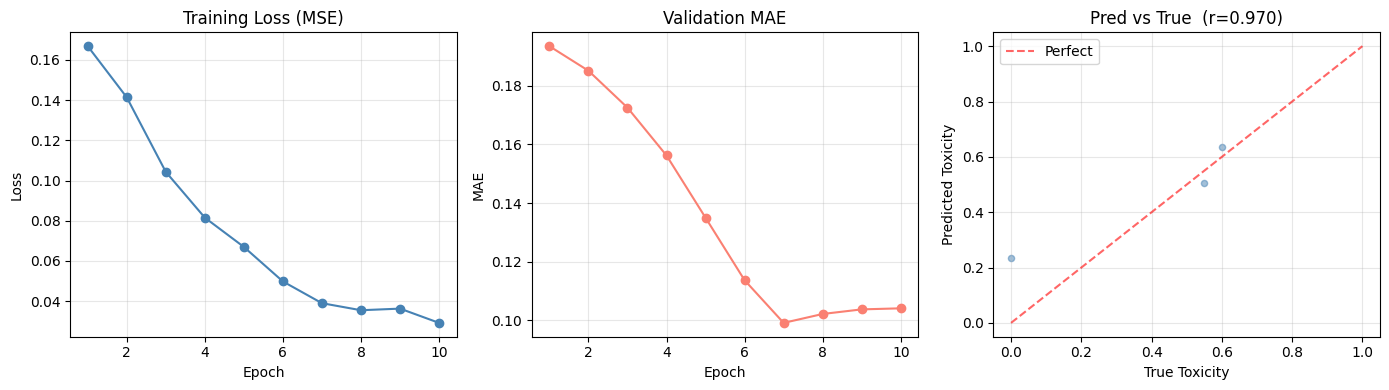

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Training loss
axes[0].plot(range(1, EPOCHS+1), train_losses, marker='o', color='steelblue')
axes[0].set_title('Training Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

# Val MAE
axes[1].plot(range(1, EPOCHS+1), val_maes, marker='o', color='salmon')
axes[1].set_title('Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].grid(alpha=0.3)

# Predicted vs true
axes[2].scatter(labels_arr, preds_arr, alpha=0.5, s=20, color='steelblue')
axes[2].plot([0,1],[0,1],'r--', alpha=0.6, label='Perfect')
axes[2].set_title(f'Pred vs True  (r={pearson:.3f})')
axes[2].set_xlabel('True Toxicity')
axes[2].set_ylabel('Predicted Toxicity')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Predict Any Comment

In [ ]:
def score(comment: str) -> float:
    model.eval()
    enc = TOKENIZER(
        comment, max_length=MAX_LEN,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        s = model(enc['input_ids'].to(device), enc['attention_mask'].to(device)).item()
    bar   = '█' * int(s * 30)
    label = 'CLEAN' if s < 0.3 else ('MILD' if s < 0.6 else ('HIGH' if s < 0.85 else 'SEVERE'))
    print(f'[{label:^6}] {s:.3f}  {bar}  "{comment[:80]}"')
    return s

print('─' * 80)
score('Thanks for the helpful explanation!')
score('I disagree, but I see your point.')
score('Your argument makes absolutely no sense.')
score('You are an embarrassment and should be ashamed.')
score('You should regret existing.')
score('I hope something terrible happens to you.')
score('Trash like you deserves to suffer.')

────────────────────────────────────────────────────────────────────────────────
[CLEAN ] 0.128  ███  "Thanks for the helpful explanation!"
[CLEAN ] 0.144  ████  "I disagree, but I see your point."
[ MILD ] 0.316  █████████  "Your argument makes absolutely no sense."
[ MILD ] 0.580  █████████████████  "You are an embarrassment and should be ashamed."
[ HIGH ] 0.668  ████████████████████  "You should regret existing."
[ MILD ] 0.558  ████████████████  "I hope something terrible happens to you."
[ HIGH ] 0.714  █████████████████████  "Trash like you deserves to suffer."


0.7141955494880676